# Data Preparation Notebook

##  Objective

This notebook prepares the dataset for analysis and modeling.

Reliable results start with well-prepared data —  

---

##  Main Steps

- **Data Understanding**: explore structure, variable types, and summary statistics  
- **Data Cleaning**: handle missing values, duplicates, and inconsistencies  
- **Data Transformation**: encode, scale, and engineer relevant features  
- **Validation**: ensure consistency and model readiness  



### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import dataset

 **CustomerId** : Contains random values and has no effect on customer leaving the bank.

**Surname** : Surname of the customer.

**CreditScore** : Credit score of the customer.

**Geography** : Country of the customer.

**Gender** : Gender of the customer.

**Age** : Age of the customer.

**Tenure** : Duration of credit card usage (in years).

**Balance** : Balance on the credit card account.

**NumOfProducts** : Number of bank products used by the customer.

**HasCrCard** : Indicates whether the customer has a credit card.

**IsActiveMember** : Indicates whether the customer is an active member.

**EstimatedSalary** : Estimated salary of the customer.

**Exited** : Indicates whether the customer has left the bank or not


In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()
df.rename(columns={'Exited': 'Churn'}, inplace=True)

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Churn            10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


### Drop Unnecessary Features

In [5]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

### Features Type Transformations

In [6]:
# Transform string variables to numeric
df['Gender'].unique()
df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1}).astype(int)

# Transform string variables to dummies
#df['Geography'].unique()
df = pd.get_dummies(df, columns=['Geography'], drop_first= True).astype(int)


In [7]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,1,0,0
1,608,0,41,1,83807,1,0,1,112542,0,0,1
2,502,0,42,8,159660,3,1,0,113931,1,0,0
3,699,0,39,1,0,2,0,0,93826,0,0,0
4,850,0,43,2,125510,1,1,1,79084,0,0,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CreditScore        10000 non-null  int64
 1   Gender             10000 non-null  int64
 2   Age                10000 non-null  int64
 3   Tenure             10000 non-null  int64
 4   Balance            10000 non-null  int64
 5   NumOfProducts      10000 non-null  int64
 6   HasCrCard          10000 non-null  int64
 7   IsActiveMember     10000 non-null  int64
 8   EstimatedSalary    10000 non-null  int64
 9   Churn              10000 non-null  int64
 10  Geography_Germany  10000 non-null  int64
 11  Geography_Spain    10000 non-null  int64
dtypes: int64(12)
memory usage: 937.6 KB


In [11]:
cols_numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'
       ]

#### Distribution Plots

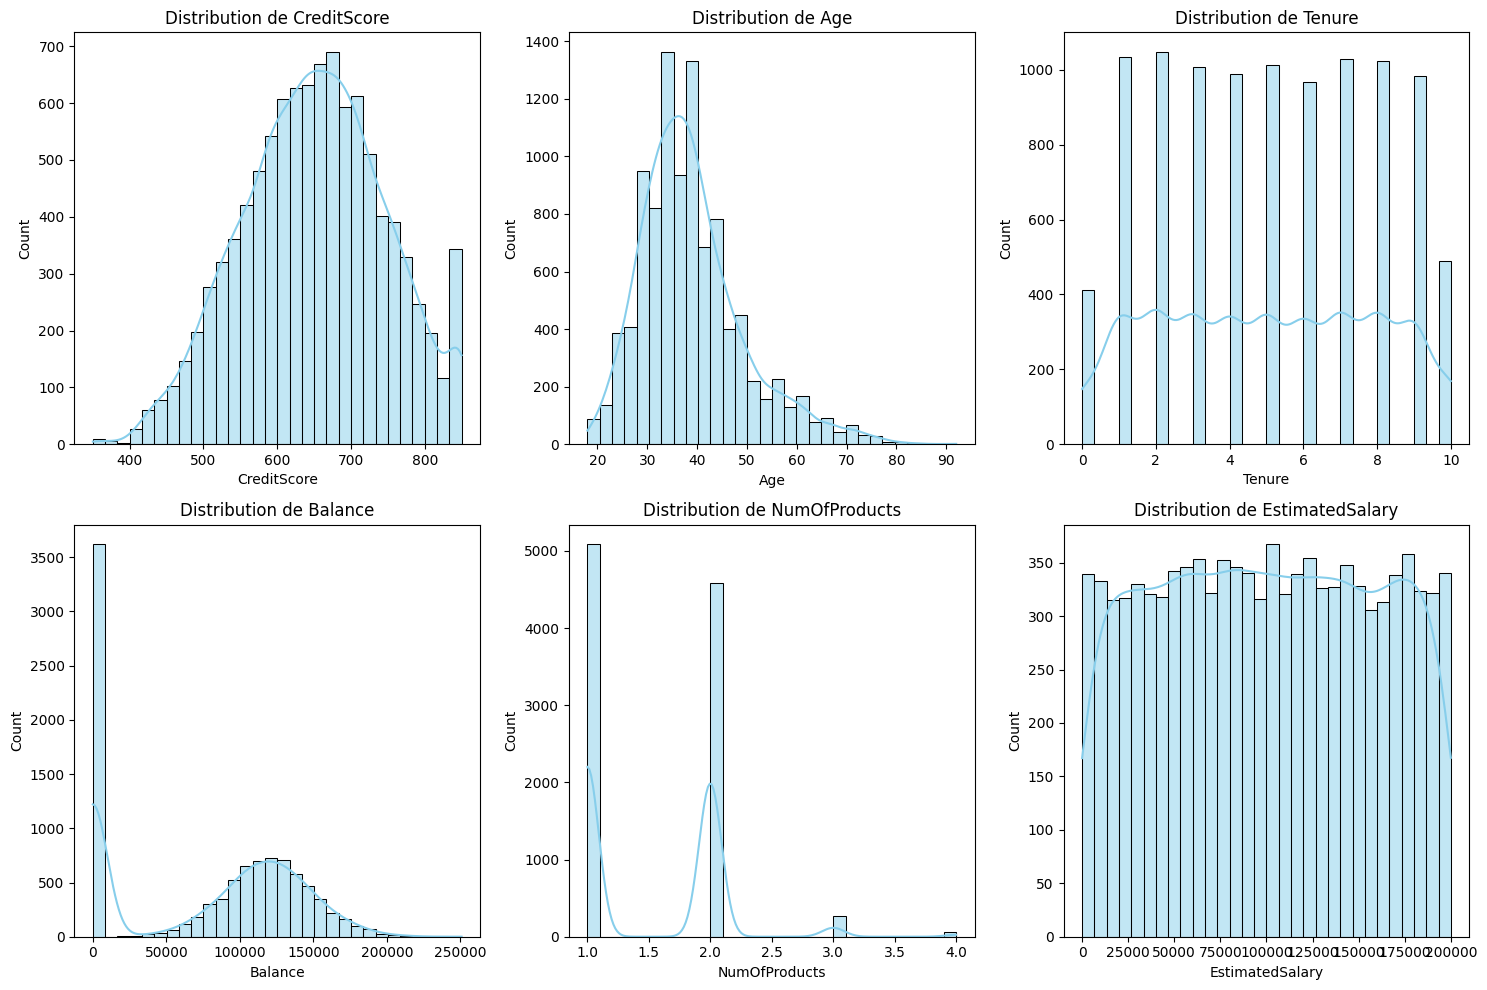

In [13]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numeric):
    plt.subplot(2, 3, i+1) 
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Export the Clean DataFrame

In [14]:
df.to_csv('BankCustomersSet_XGBoost.csv', index=False)